In [1]:
# ============================================================
# BDM Projekt SS26 — Data Quality & Anomaly Detection
# Datensatz: Fraud Detection Dataset (Kaggle)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Datensatz laden
df = pd.read_csv('Fraud Detection Dataset.csv')

# Erste Übersicht
print("=== SHAPE ===")

print(f"Zeilen: {df.shape[0]}, Spalten: {df.shape[1]}")

print("\n=== SPALTEN & DATENTYPEN ===")
print(df.dtypes)

print("\n=== ERSTE 5 ZEILEN ===")
df.head()

=== SHAPE ===
Zeilen: 51000, Spalten: 12

=== SPALTEN & DATENTYPEN ===
Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object

=== ERSTE 5 ZEILEN ===


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [2]:
# ============================================================
# BLOCK 2 — Datenprofiling
# ============================================================

print("=== FEHLENDE WERTE ===")
missing = df.isnull().sum()
missing_pct = df.isnull().sum() / len(df) * 100
missing_df = pd.DataFrame({
    'Fehlend (Anzahl)': missing,
    'Fehlend (%)': round(missing_pct, 2)
})
print(missing_df[missing_df['Fehlend (Anzahl)'] > 0])

print("\n=== DUPLIKATE ===")
print(f"Doppelte Transaction_IDs: {df['Transaction_ID'].duplicated().sum()}")
print(f"Komplette Zeilen-Duplikate: {df.duplicated().sum()}")

print("\n=== VERDÄCHTIGE WERTE ===")
print(f"'Unknown Device' in Device_Used: {(df['Device_Used'] == 'Unknown Device').sum()}")
print(f"'Invalid Method' in Payment_Method: {(df['Payment_Method'] == 'Invalid Method').sum()}")

print("\n=== STATISTIK ===")
df.describe()

=== FEHLENDE WERTE ===
                     Fehlend (Anzahl)  Fehlend (%)
Transaction_Amount               2520         4.94
Time_of_Transaction              2552         5.00
Device_Used                      2473         4.85
Location                         2547         4.99
Payment_Method                   2469         4.84

=== DUPLIKATE ===
Doppelte Transaction_IDs: 1000
Komplette Zeilen-Duplikate: 881

=== VERDÄCHTIGE WERTE ===
'Unknown Device' in Device_Used: 1530
'Invalid Method' in Payment_Method: 1530

=== STATISTIK ===


,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


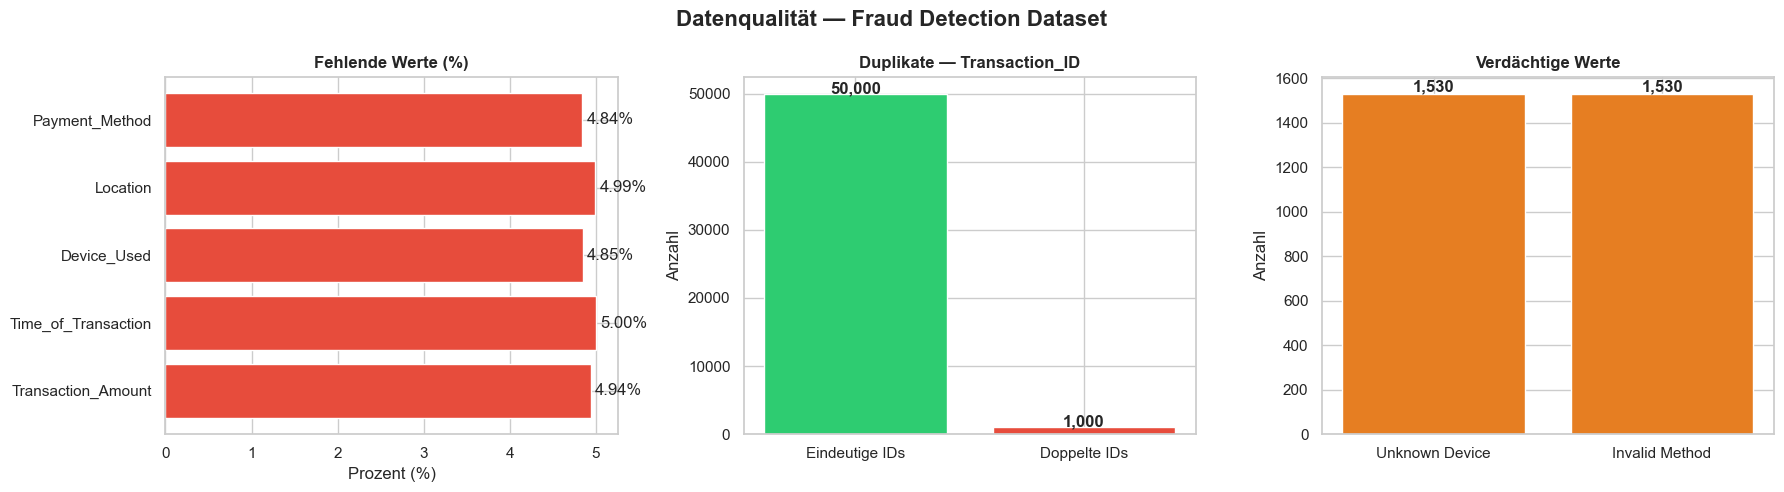

In [3]:
# ============================================================
# BLOCK 3 — Visualisierung
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Datenqualität — Fraud Detection Dataset', fontsize=16, fontweight='bold')

# Plot 1: Fehlende Werte ---
missing_pct = df.isnull().sum() / len(df) * 100
missing_pct = missing_pct[missing_pct > 0]

axes[0].barh(missing_pct.index, missing_pct.values, color='#E74C3C')
axes[0].set_title('Fehlende Werte (%)', fontweight='bold')
axes[0].set_xlabel('Prozent (%)')
for i, v in enumerate(missing_pct.values):
    axes[0].text(v + 0.05, i, f'{v:.2f}%', va='center')

# Plot 2: Duplikate ---
dup_labels = ['Eindeutige IDs', 'Doppelte IDs']
dup_values = [len(df) - df['Transaction_ID'].duplicated().sum(), 
              df['Transaction_ID'].duplicated().sum()]

axes[1].bar(dup_labels, dup_values, color=['#2ECC71', '#E74C3C'])
axes[1].set_title('Duplikate — Transaction_ID', fontweight='bold')
axes[1].set_ylabel('Anzahl')
for i, v in enumerate(dup_values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Plot 3: Verdächtige Werte ---
sus_labels = ['Unknown Device', 'Invalid Method']
sus_values = [
    (df['Device_Used'] == 'Unknown Device').sum(),
    (df['Payment_Method'] == 'Invalid Method').sum()
]

axes[2].bar(sus_labels, sus_values, color='#E67E22')
axes[2].set_title('Verdächtige Werte', fontweight='bold')
axes[2].set_ylabel('Anzahl')
for i, v in enumerate(sus_values):
    axes[2].text(i, v + 10, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('datenqualitaet.png', dpi=150, bbox_inches='tight')
plt.show()


In [4]:
# ============================================================
# BLOCK 3b — Datentypen
# ============================================================

print("=== DATENTYPEN ===")
print(df.dtypes)

print("\n=== PROBLEM: Spalten die numerisch sein sollten ===")
print(f"Transaction_Amount Typ: {df['Transaction_Amount'].dtype} ")
print(f"Time_of_Transaction Typ: {df['Time_of_Transaction'].dtype} ")
print(f"Fraudulent Typ: {df['Fraudulent'].dtype} ")
print(f"Transaction_ID Typ: {df['Transaction_ID'].dtype} — Text, nicht Zahl (normal)")
print(f"Device_Used Typ: {df['Device_Used'].dtype} — Text (normal)")
print(f"Payment_Method Typ: {df['Payment_Method'].dtype} — Text (normal)")

=== DATENTYPEN ===
Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object

=== PROBLEM: Spalten die numerisch sein sollten ===
Transaction_Amount Typ: float64 
Time_of_Transaction Typ: float64 
Fraudulent Typ: int64 
Transaction_ID Typ: object — Text, nicht Zahl (normal)
Device_Used Typ: object — Text (normal)
Payment_Method Typ: object — Text (normal)


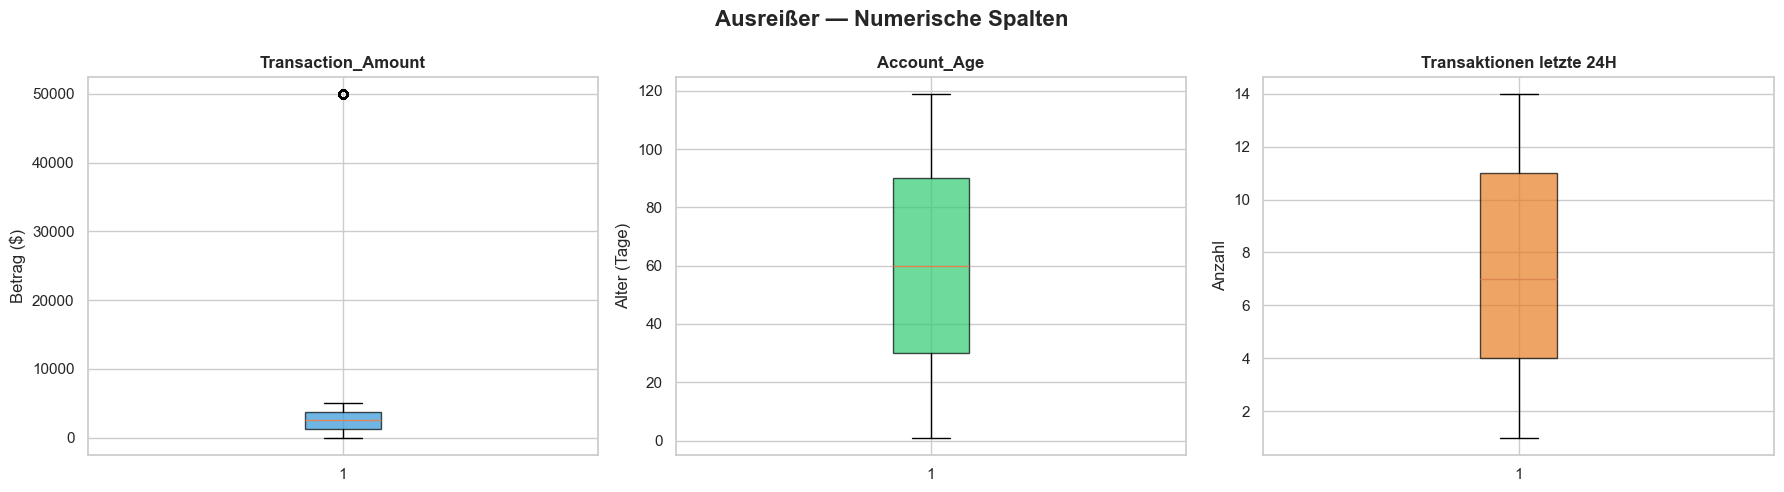

=== AUSREISSER (IQR-Methode) ===

Transaction_Amount:
  Untere Grenze: -2504.48
  Obere Grenze: 7562.27
  Anzahl Ausreißer: 508

Account_Age:
  Untere Grenze: -60.00
  Obere Grenze: 180.00
  Anzahl Ausreißer: 0

Number_of_Transactions_Last_24H:
  Untere Grenze: -6.50
  Obere Grenze: 21.50
  Anzahl Ausreißer: 0


In [5]:
# ============================================================
# BLOCK 4 — Ausreißer (Outliers)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ausreißer — Numerische Spalten', fontsize=16, fontweight='bold')

# Plot 1: Transaction_Amount ---
axes[0].boxplot(df['Transaction_Amount'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#3498DB', alpha=0.7))
axes[0].set_title('Transaction_Amount', fontweight='bold')
axes[0].set_ylabel('Betrag ($)')

# Plot 2: Account_Age ---
axes[1].boxplot(df['Account_Age'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#2ECC71', alpha=0.7))
axes[1].set_title('Account_Age', fontweight='bold')
axes[1].set_ylabel('Alter (Tage)')

# Plot 3: Number_of_Transactions_Last_24H ---
axes[2].boxplot(df['Number_of_Transactions_Last_24H'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#E67E22', alpha=0.7))
axes[2].set_title('Transaktionen letzte 24H', fontweight='bold')
axes[2].set_ylabel('Anzahl')

plt.tight_layout()
plt.savefig('ausreisser.png', dpi=150, bbox_inches='tight')
plt.show()

# Ausreißer berechnen mit IQR-Methode
print("=== AUSREISSER (IQR-Methode) ===")
for col in ['Transaction_Amount', 'Account_Age', 'Number_of_Transactions_Last_24H']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    untere_grenze = Q1 - 1.5 * IQR
    obere_grenze = Q3 + 1.5 * IQR
    ausreisser = df[(df[col] < untere_grenze) | (df[col] > obere_grenze)]
    print(f"\n{col}:")
    print(f"  Untere Grenze: {untere_grenze:.2f}")
    print(f"  Obere Grenze: {obere_grenze:.2f}")
    print(f"  Anzahl Ausreißer: {len(ausreisser)}")

In [6]:
# ============================================================
# BLOCK 5 — Quality-Checks (5 Regeln)
# ============================================================

print("=== QUALITY-CHECKS ===\n")

# QC1: Transaction_Amount muss positiv sein
qc1 = df[df['Transaction_Amount'] <= 0]
print(f"QC1 — Transaction_Amount <= 0: {len(qc1)} Verstöße")

# QC2: Keine doppelten Transaction_IDs
qc2 = df['Transaction_ID'].duplicated().sum()
print(f"QC2 — Doppelte Transaction_IDs: {qc2} Verstöße")

# QC3: Time_of_Transaction muss zwischen 0 und 23 liegen
qc3 = df[(df['Time_of_Transaction'] < 0) | (df['Time_of_Transaction'] > 23)]
print(f"QC3 — Time_of_Transaction außerhalb 0-23: {len(qc3)} Verstöße")

# QC4: Fraudulent darf nur 0 oder 1 sein
qc4 = df[~df['Fraudulent'].isin([0, 1])]
print(f"QC4 — Fraudulent nicht 0/1: {len(qc4)} Verstöße")

# QC5: Payment_Method und Device_Used dürfen nicht "Invalid"/"Unknown" sein
qc5_a = (df['Payment_Method'] == 'Invalid Method').sum()
qc5_b = (df['Device_Used'] == 'Unknown Device').sum()
print(f"QC5 — Invalid Method: {qc5_a} Verstöße")
print(f"QC5 — Unknown Device: {qc5_b} Verstöße")

# Zusammenfassung
print("\n=== ZUSAMMENFASSUNG ===")
total_checks = 5
failed_checks = sum([len(qc1) > 0, qc2 > 0, len(qc3) > 0, len(qc4) > 0, (qc5_a + qc5_b) > 0])
print(f"Checks insgesamt: {total_checks}")
print(f"Checks mit Verstößen: {failed_checks}")
print(f"Checks ohne Verstöße: {total_checks - failed_checks}")

=== QUALITY-CHECKS ===

QC1 — Transaction_Amount <= 0: 0 Verstöße
QC2 — Doppelte Transaction_IDs: 1000 Verstöße
QC3 — Time_of_Transaction außerhalb 0-23: 0 Verstöße
QC4 — Fraudulent nicht 0/1: 0 Verstöße
QC5 — Invalid Method: 1530 Verstöße
QC5 — Unknown Device: 1530 Verstöße

=== ZUSAMMENFASSUNG ===
Checks insgesamt: 5
Checks mit Verstößen: 2
Checks ohne Verstöße: 3


In [7]:
# ============================================================
# BLOCK 6 — Isolation Forest
# ============================================================

from sklearn.ensemble import IsolationForest

# Vorbereitung: nur numerische Spalten, fehlende Werte entfernen
features = ['Transaction_Amount', 'Time_of_Transaction', 
             'Previous_Fraudulent_Transactions', 'Account_Age', 
             'Number_of_Transactions_Last_24H']

df_model = df.dropna(subset=features).copy()
print(f"Zeilen vor dropna: {len(df)}")
print(f"Zeilen nach dropna: {len(df_model)}")

X = df_model[features]

# Isolation Forest trainieren
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_model['anomaly'] = iso_forest.fit_predict(X)

# -1 = Anomalie, 1 = normal
df_model['anomaly_label'] = df_model['anomaly'].map({1: 'Normal', -1: 'Anomalie'})

print("\n=== ERGEBNIS ===")
print(df_model['anomaly_label'].value_counts())

Zeilen vor dropna: 51000
Zeilen nach dropna: 46065

=== ERGEBNIS ===
anomaly_label
Normal      43761
Anomalie     2304
Name: count, dtype: int64


In [8]:
# ============================================================2
# BLOCK 7 — Vergleich: Anomalien vs. echte Fraud-Labels
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report

# Anomalie (-1) → 1, Normal (1) → 0  (gleiche Kodierung wie Fraudulent)
df_model['anomaly_binary'] = df_model['anomaly'].map({-1: 1, 1: 0})

# Confusion Matrix
cm = confusion_matrix(df_model['Fraudulent'], df_model['anomaly_binary'])
print("=== CONFUSION MATRIX ===")
print("                 Vorhergesagt: Normal | Vorhergesagt: Anomalie")
print(f"Tatsächlich Normal:    {cm[0][0]:>8}        |  {cm[0][1]:>8}")
print(f"Tatsächlich Fraud:     {cm[1][0]:>8}        |  {cm[1][1]:>8}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(df_model['Fraudulent'], df_model['anomaly_binary'], 
                              target_names=['Normal', 'Fraud']))

# Wie viel Prozent der echten Fraud-Fälle wurden gefunden?
total_fraud = df_model['Fraudulent'].sum()
found_fraud = cm[1][1]
print(f"\nEchte Fraud-Fälle insgesamt: {total_fraud}")
print(f"Davon von Isolation Forest als Anomalie erkannt: {found_fraud}")
print(f"Erkennungsrate: {found_fraud/total_fraud*100:.1f}%")

=== CONFUSION MATRIX ===
                 Vorhergesagt: Normal | Vorhergesagt: Anomalie
Tatsächlich Normal:       41622        |      2184
Tatsächlich Fraud:         2139        |       120

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95     43806
       Fraud       0.05      0.05      0.05      2259

    accuracy                           0.91     46065
   macro avg       0.50      0.50      0.50     46065
weighted avg       0.91      0.91      0.91     46065


Echte Fraud-Fälle insgesamt: 2259
Davon von Isolation Forest als Anomalie erkannt: 120
Erkennungsrate: 5.3%


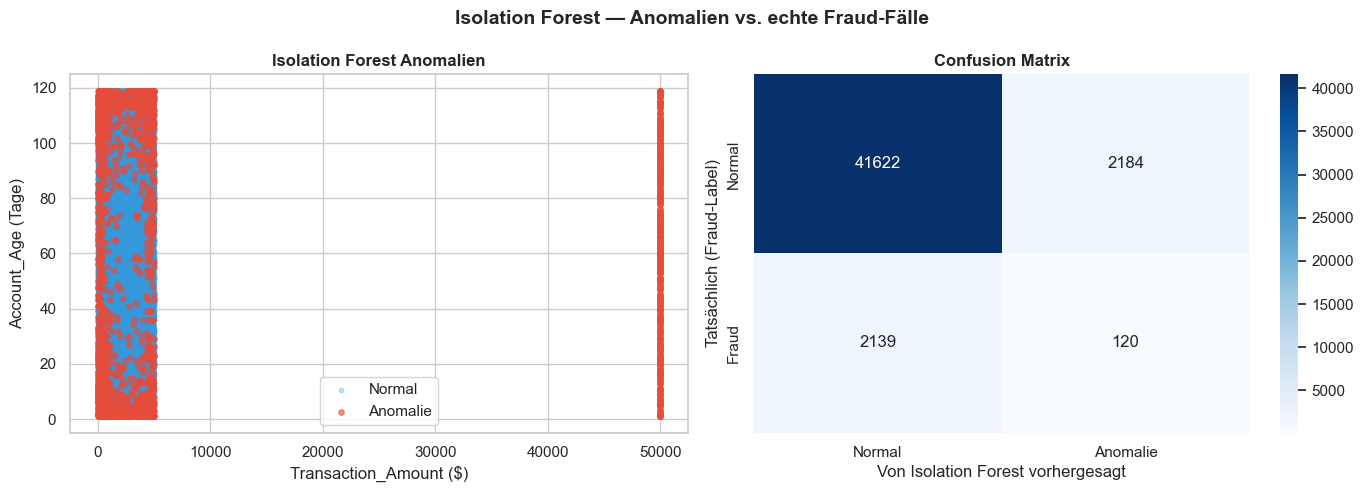

In [9]:
# ============================================================
# BLOCK 8 — Visualisierung: Anomalien vs. Fraud
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Isolation Forest — Anomalien vs. echte Fraud-Fälle', fontsize=14, fontweight='bold')

# Plot 1: Transaction_Amount nach Anomalie-Status ---
axes[0].scatter(df_model[df_model['anomaly_label']=='Normal']['Transaction_Amount'],
                df_model[df_model['anomaly_label']=='Normal']['Account_Age'],
                alpha=0.3, s=10, color='#3498DB', label='Normal')
axes[0].scatter(df_model[df_model['anomaly_label']=='Anomalie']['Transaction_Amount'],
                df_model[df_model['anomaly_label']=='Anomalie']['Account_Age'],
                alpha=0.6, s=15, color='#E74C3C', label='Anomalie')
axes[0].set_title('Isolation Forest Anomalien', fontweight='bold')
axes[0].set_xlabel('Transaction_Amount ($)')
axes[0].set_ylabel('Account_Age (Tage)')
axes[0].legend()

# Plot 2: Confusion Matrix als Heatmap ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Anomalie'],
            yticklabels=['Normal', 'Fraud'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Von Isolation Forest vorhergesagt')
axes[1].set_ylabel('Tatsächlich (Fraud-Label)')

plt.tight_layout()
plt.savefig('isolation_forest_ergebnis.png', dpi=150, bbox_inches='tight')
plt.show()
